# Named Entity Recognition for Medical Texts

## Extracting Diseases, Chemicals, and Symptoms from Clinical Reports

**Project:** Fine-tuning BioBERT for Medical NER  
**Authors:** Samuel Endale (UGR/9314/14), Simon Dereje (UGR/0952/14)  
**Advisor:** Mr. Debela Desalegn Yadeta  
**Institution:** Addis Ababa University

---

### Notebook Overview

This notebook implements a Named Entity Recognition (NER) system for medical texts using BioBERT. The system extracts:
- **Diseases** from medical reports
- **Chemicals/Drugs** from clinical literature
- **Symptoms** (requires additional datasets)

### Structure

1. **Setup & Installation**: Package installation and imports
2. **Dataset Preparation**: Download, load, combine, and trim NCBI Disease and BC5CDR datasets
3. **Model Preprocessing**: BERT tokenization and label alignment
4. **Model Training**: BioBERT fine-tuning with cross-entropy loss
5. **Evaluation**: Test set metrics and per-entity performance
6. **Error Analysis**: Confusion matrix and error patterns
7. **Visualization**: SpaCy visualization for entity extraction
8. **Model Persistence**: Save and load trained models

---

**Note:** Run cells sequentially from top to bottom. Some cells may take several minutes to execute.

In [1]:
# ==========================================
# INSTALLATION & IMPORTS
# ==========================================
# Install required packages
# Note: After running this cell, restart the runtime (Runtime > Restart Session)
!pip install transformers datasets seqeval spacy accelerate matplotlib evaluate seaborn scikit-learn

# Standard library imports
import os
import re
import random
from collections import Counter
import requests

# Data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import spacy
from spacy import displacy

# Hugging Face / Transformers
from transformers import (
    AutoTokenizer, 
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
from datasets import (
    load_dataset, 
    Dataset, 
    DatasetDict, 
    ClassLabel, 
    Features, 
    Sequence, 
    Value
)
import evaluate

# Other utilities
import torch
import nltk

# Disable wandb logging
os.environ["WANDB_DISABLED"] = "true"

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✓ All packages installed and imports loaded successfully!")



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\SAMI\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All packages installed and imports loaded successfully!


## Part 1: Dataset Preparation

This section downloads, loads, combines, and preprocesses the NCBI Disease Corpus and BC5CDR datasets.

In [2]:
# ==========================================
# Dataset Downloading
# ==========================================


def parse_conll_content(content):
    data = {"tokens": [], "ner_tags": []}
    tokens, tags = [], []
    for line in content.strip().split("\n"):
        line = line.strip()
        if not line:
            if tokens:
                data["tokens"].append(tokens)
                data["ner_tags"].append(tags)
                tokens, tags = [], []
        else:
            parts = line.split()
            if len(parts) >= 2:
                tokens.append(parts[0])
                tags.append(parts[-1])
    if tokens:
        data["tokens"].append(tokens)
        data["ner_tags"].append(tags)
    return data


def download_and_parse(url):
    r = requests.get(url)
    r.raise_for_status()
    r.encoding = r.encoding or "utf-8"
    return parse_conll_content(r.text)


print("Downloading NCBI Disease dataset from GitHub (into memory)...")
ncbi_urls = {
    "train": "https://raw.githubusercontent.com/spyysalo/ncbi-disease/master/conll/train.tsv",
    "validation": "https://raw.githubusercontent.com/spyysalo/ncbi-disease/master/conll/devel.tsv",
    "test": "https://raw.githubusercontent.com/spyysalo/ncbi-disease/master/conll/test.tsv"
}
ncbi_train = download_and_parse(ncbi_urls["train"])
ncbi_val = download_and_parse(ncbi_urls["validation"])
ncbi_test = download_and_parse(ncbi_urls["test"])
print("✓ NCBI train, validation, test loaded into memory")

print("\nDownloading BC5CDR dataset from GitHub (into memory)...")


def _empty_data():
    return {"tokens": [], "ner_tags": []}


bc5cdr_chem_train, bc5cdr_chem_val, bc5cdr_chem_test = _empty_data(
), _empty_data(), _empty_data()
bc5cdr_disease_train, bc5cdr_disease_val, bc5cdr_disease_test = _empty_data(
), _empty_data(), _empty_data()
bc5cdr_urls = {
    "train": "https://raw.githubusercontent.com/cambridgeltl/MTL-Bioinformatics-2016/master/data/BC5CDR-chem-IOB/train.tsv",
    "validation": "https://raw.githubusercontent.com/cambridgeltl/MTL-Bioinformatics-2016/master/data/BC5CDR-chem-IOB/devel.tsv",
    "test": "https://raw.githubusercontent.com/cambridgeltl/MTL-Bioinformatics-2016/master/data/BC5CDR-chem-IOB/test.tsv"
}
bc5cdr_disease_urls = {
    "train": "https://raw.githubusercontent.com/cambridgeltl/MTL-Bioinformatics-2016/master/data/BC5CDR-disease-IOB/train.tsv",
    "validation": "https://raw.githubusercontent.com/cambridgeltl/MTL-Bioinformatics-2016/master/data/BC5CDR-disease-IOB/devel.tsv",
    "test": "https://raw.githubusercontent.com/cambridgeltl/MTL-Bioinformatics-2016/master/data/BC5CDR-disease-IOB/test.tsv"
}
for split, url in bc5cdr_urls.items():
    try:
        d = download_and_parse(url)
        if split == "train":
            bc5cdr_chem_train = d
        elif split == "validation":
            bc5cdr_chem_val = d
        else:
            bc5cdr_chem_test = d
        print(f"✓ bc5cdr_chem_{split}")
    except Exception as e:
        print(f"⚠ BC5CDR chemical {split}: {e}")
for split, url in bc5cdr_disease_urls.items():
    try:
        d = download_and_parse(url)
        if split == "train":
            bc5cdr_disease_train = d
        elif split == "validation":
            bc5cdr_disease_val = d
        else:
            bc5cdr_disease_test = d
        print(f"✓ bc5cdr_disease_{split}")
    except Exception as e:
        print(f"⚠ BC5CDR disease {split}: {e}")

✓ NCBI train, validation, test loaded into memory

✓ bc5cdr_chem_train
✓ bc5cdr_chem_validation
✓ bc5cdr_chem_test
✓ bc5cdr_disease_train
✓ bc5cdr_disease_validation
✓ bc5cdr_disease_test


In [ ]:
# ==========================================
# Dataset Combination and Trimming
# ==========================================

def merge_bc5cdr_annotations(chem_data, disease_data):
    """Merge BC5CDR chemical and disease annotations, prioritizing disease tags"""
    merged = {"tokens": [], "ner_tags": []}

    for i, tokens in enumerate(chem_data["tokens"]):
        if i < len(disease_data["tokens"]) and tokens == disease_data["tokens"][i]:
            chem_tags = chem_data["ner_tags"][i]
            disease_tags = disease_data["ner_tags"][i]
            merged_tags = []
            for j, (ct, dt) in enumerate(zip(chem_tags, disease_tags)):
                # Priority: Disease > Chemical > O
                if dt != "O":
                    merged_tags.append(dt)
                elif ct != "O":
                    merged_tags.append(ct)
                else:
                    merged_tags.append("O")
            merged["tokens"].append(tokens)
            merged["ner_tags"].append(merged_tags)
        elif tokens:
            merged["tokens"].append(tokens)
            merged["ner_tags"].append(chem_data["ner_tags"][i])

    return merged


# Merge BC5CDR annotations
if bc5cdr_chem_train["tokens"] and bc5cdr_disease_train["tokens"]:
    bc5cdr_train = merge_bc5cdr_annotations(
        bc5cdr_chem_train, bc5cdr_disease_train)
    bc5cdr_val = merge_bc5cdr_annotations(bc5cdr_chem_val, bc5cdr_disease_val)
    bc5cdr_test = merge_bc5cdr_annotations(
        bc5cdr_chem_test, bc5cdr_disease_test)
else:
    bc5cdr_train = bc5cdr_chem_train if bc5cdr_chem_train["tokens"] else {
        "tokens": [], "ner_tags": []}
    bc5cdr_val = bc5cdr_chem_val if bc5cdr_chem_val["tokens"] else {
        "tokens": [], "ner_tags": []}
    bc5cdr_test = bc5cdr_chem_test if bc5cdr_chem_test["tokens"] else {
        "tokens": [], "ner_tags": []}

# Combine datasets


def combine_datasets(dataset1, dataset2):
    """Combine two datasets by concatenating their examples"""
    combined = {
        "tokens": dataset1["tokens"] + dataset2["tokens"],
        "ner_tags": dataset1["ner_tags"] + dataset2["ner_tags"]
    }
    return combined


print("Combining NCBI Disease and BC5CDR datasets...")
combined_train = combine_datasets(
    ncbi_train, bc5cdr_train) if bc5cdr_train["tokens"] else ncbi_train
combined_val = combine_datasets(
    ncbi_val, bc5cdr_val) if bc5cdr_val["tokens"] else ncbi_val
combined_test = combine_datasets(
    ncbi_test, bc5cdr_test) if bc5cdr_test["tokens"] else ncbi_test

# Dataset trimming function


def trim_dataset(data, trim_ratio=0.3, random_seed=42):
    """Trim dataset to specified ratio while maintaining class balance"""
    random.seed(random_seed)

    if not data["tokens"]:
        return data

    original_size = len(data["tokens"])
    target_size = int(original_size * trim_ratio)

    if target_size >= original_size:
        return data

    indices = list(range(original_size))
    sampled_indices = random.sample(indices, target_size)
    sampled_indices.sort()

    trimmed = {
        "tokens": [data["tokens"][i] for i in sampled_indices],
        "ner_tags": [data["ner_tags"][i] for i in sampled_indices]
    }

    print(
        f"  Trimmed from {original_size} to {len(trimmed['tokens'])} examples ({trim_ratio*100:.1f}%)")
    return trimmed


# Trim datasets for training efficiency
print("\nTrimming datasets for training efficiency...")
TRIM_RATIO = 0.3  # Keep 30% of data
trimmed_train = trim_dataset(combined_train, trim_ratio=TRIM_RATIO)
trimmed_val = trim_dataset(combined_val, trim_ratio=TRIM_RATIO)
trimmed_test = trim_dataset(combined_test, trim_ratio=TRIM_RATIO)

# Get all unique tags and create mappings
all_tags_set = set()
for row in trimmed_train["ner_tags"]:
    all_tags_set.update(row)

all_tags = sorted(list(all_tags_set))
if "O" in all_tags:
    all_tags.remove("O")
    all_tags = ["O"] + all_tags

tag2id = {tag: i for i, tag in enumerate(all_tags)}
id2label = {i: tag for i, tag in enumerate(all_tags)}

print(f"\nDetected Entity Tags: {all_tags}")
print(f"Total unique tags: {len(all_tags)}")

# Build Hugging Face Dataset


def build_hf_dataset(raw_data, tag2id_map, all_tags_list):
    """Convert raw data to Hugging Face Dataset format"""
    ner_tags_ids = [[tag2id_map.get(t, 0) for t in seq]
                    for seq in raw_data["ner_tags"]]

    d = Dataset.from_dict({
        "tokens": raw_data["tokens"],
        "ner_tags": ner_tags_ids
    })

    features = Features({
        "tokens": Sequence(Value("string")),
        "ner_tags": Sequence(ClassLabel(names=all_tags_list))
    })
    return d.cast(features)


dataset = DatasetDict({
    "train": build_hf_dataset(trimmed_train, tag2id, all_tags),
    "validation": build_hf_dataset(trimmed_val, tag2id, all_tags),
    "test": build_hf_dataset(trimmed_test, tag2id, all_tags)
})

print("\n" + "="*60)
print("Dataset Summary:")
print(f"  Training examples: {len(dataset['train'])}")
print(f"  Validation examples: {len(dataset['validation'])}")
print(f"  Test examples: {len(dataset['test'])}")
print(f"  Entity types: {[tag for tag in all_tags if tag != 'O']}")
print("="*60)
print("\n✓ Dataset preparation completed!")
print("Sample Data:", dataset["train"][0])

Combining NCBI Disease and BC5CDR datasets...

Trimming datasets for training efficiency...
  Trimmed from 9992 to 2997 examples (30.0%)
  Trimmed from 5504 to 1651 examples (30.0%)
  Trimmed from 5737 to 1721 examples (30.0%)

Detected Entity Tags: ['O', 'B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease']
Total unique tags: 5


Casting the dataset: 100%|██████████| 1721/1721 [00:00<00:00, 160981.20 examples/s]


Dataset Summary:
  Training examples: 2997
  Validation examples: 1651
  Test examples: 1721
  Entity types: ['B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease']

✓ Dataset preparation completed!
Sample Data: {'tokens': ['Like', 'APC', ',', 'APC2', 'regulates', 'the', 'formation', 'of', 'active', 'betacatenin', '-', 'Tcf', 'complexes', ',', 'as', 'demonstrated', 'using', 'transient', 'transcriptional', 'activation', 'assays', 'in', 'APC', '-', '/', '-', 'colon', 'carcinoma', 'cells', '.'], 'ner_tags': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}


## Part 2: Model Preprocessing


In [4]:
# ==========================================
# BERT Tokenization and Label Alignment
# ==========================================

# Initialize BioBERT tokenizer
model_checkpoint = "dmis-lab/biobert-v1.1"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)


def tokenize_and_align_labels(examples):
    """Tokenize text and align labels to subword tokens"""
    tokenized_inputs = tokenizer(
        examples["tokens"], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                # Special tokens ([CLS], [SEP]) get -100 (ignored in loss)
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                # First subword token of a word gets the label
                label_ids.append(label[word_idx])
            else:
                # Subsequent subword tokens get -100
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs


# Apply tokenization to all datasets
tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)

print("✓ Tokenization completed!")
print(f"  Tokenized train examples: {len(tokenized_datasets['train'])}")
print(
    f"  Tokenized validation examples: {len(tokenized_datasets['validation'])}")
print(f"  Tokenized test examples: {len(tokenized_datasets['test'])}")

Map: 100%|██████████| 1721/1721 [00:00<00:00, 7650.21 examples/s]

✓ Tokenization completed!
  Tokenized train examples: 2997
  Tokenized validation examples: 1651
  Tokenized test examples: 1721


## Part 4: Model Training

Initialize BioBERT model, configure training arguments, and fine-tune for token classification.

In [5]:
# ==========================================
# Model Initialization
# ==========================================

# Create label mappings
label_list = dataset["train"].features["ner_tags"].feature.names
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

# Initialize BioBERT model for token classification
model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

# Load seqeval metric for evaluation
seqeval = evaluate.load("seqeval")


def compute_metrics(p):
    """Compute precision, recall, F1-score using seqeval"""
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(
        predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }


# Configure training arguments
training_args = TrainingArguments(
    output_dir="biobert_ner_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=2,
    fp16=torch.cuda.is_available(),
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

# Create data collator and trainer
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("✓ Model initialization completed!")
print(f"  Model: {model_checkpoint}")
print(f"  Number of labels: {len(label_list)}")
print(f"  Labels: {label_list}")

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


✓ Model initialization completed!
  Model: dmis-lab/biobert-v1.1
  Number of labels: 5
  Labels: ['O', 'B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease']


C:\Users\SAMI\AppData\Local\Temp\ipykernel_10588\159681754.py:62: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [6]:
# ==========================================
# Model Training
# ==========================================
# Note: Training may take 30-60 minutes depending on GPU availability

print("Starting training...")
trainer.train()
print("\n✓ Training completed!")
print(f"Best model saved at: {training_args.output_dir}")

Starting training...


c:\Users\SAMI\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.098399,0.784378,0.833386,0.808140,0.966378
2,No log,0.088872,0.805966,0.844115,0.824599,0.969567


c:\Users\SAMI\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



✓ Training completed!
Best model saved at: biobert_ner_model


## Part 5: Evaluation

Evaluate model performance on test set with comprehensive metrics and error analysis.

In [7]:
# ==========================================
# Test Set Evaluation
# ==========================================

print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)

# Evaluate on test set
test_results = trainer.evaluate(eval_dataset=tokenized_datasets["test"])

print("\nTest Set Performance Metrics:")
print(f"  Precision: {test_results.get('eval_precision', 0):.4f}")
print(f"  Recall: {test_results.get('eval_recall', 0):.4f}")
print(f"  F1-Score: {test_results.get('eval_f1', 0):.4f}")
print(f"  Accuracy: {test_results.get('eval_accuracy', 0):.4f}")

# Per-entity-type metrics
print("\n" + "-"*60)
print("PER-ENTITY-TYPE METRICS")
print("-"*60)

# Get predictions on test set
test_predictions = trainer.predict(tokenized_datasets["test"])
test_preds = np.argmax(test_predictions.predictions, axis=2)

# Convert to label strings
true_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(test_preds, test_predictions.label_ids)
]
true_labels = [
    [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(test_preds, test_predictions.label_ids)
]

# Calculate per-entity metrics using seqeval
results = seqeval.compute(predictions=true_predictions, references=true_labels)

# Extract per-entity metrics
entity_types = [tag for tag in all_tags if tag != 'O']
print("\nPer-Entity Performance:")
for entity in entity_types:
    if entity in results:
        print(f"\n  {entity}:")
        print(f"    Precision: {results[entity]['precision']:.4f}")
        print(f"    Recall: {results[entity]['recall']:.4f}")
        print(f"    F1-Score: {results[entity]['f1']:.4f}")
        print(f"    Number: {results[entity]['number']}")

print("\n" + "="*60)


TEST SET EVALUATION


c:\Users\SAMI\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Test Set Performance Metrics:
  Precision: 0.8070
  Recall: 0.8366
  F1-Score: 0.8215
  Accuracy: 0.9687

------------------------------------------------------------
PER-ENTITY-TYPE METRICS
------------------------------------------------------------

Per-Entity Performance:




ERROR ANALYSIS


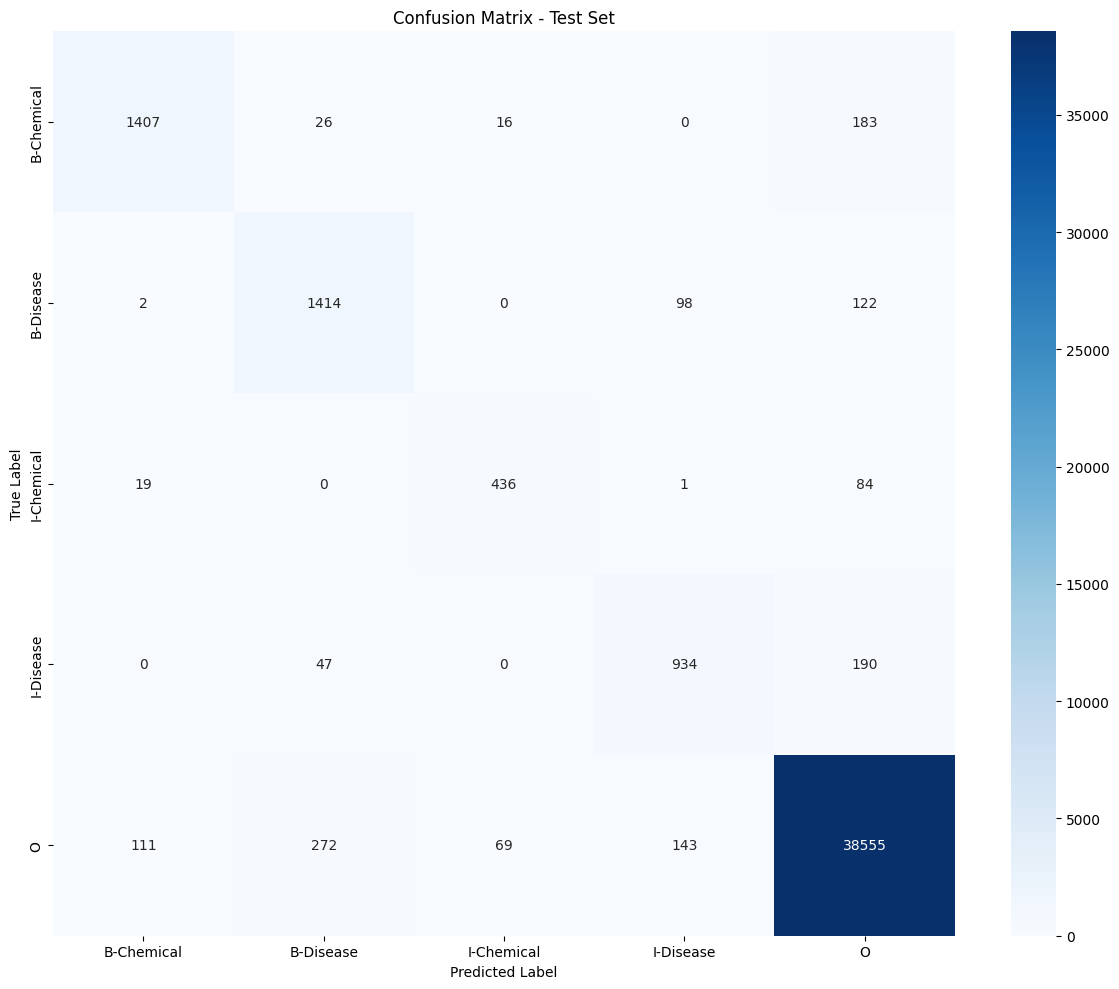

In [8]:
# ==========================================
# Error Analysis
# ==========================================

from sklearn.metrics import confusion_matrix

print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)

# Flatten predictions and labels for confusion matrix
flat_true = [label for seq in true_labels for label in seq]
flat_pred = [pred for seq in true_predictions for pred in seq]

# Get unique labels for confusion matrix
unique_labels = sorted(list(set(flat_true + flat_pred)))
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}

# Create confusion matrix
cm = confusion_matrix(
    [label_to_idx[label] for label in flat_true],
    [label_to_idx[label] for label in flat_pred],
    labels=[label_to_idx[label] for label in unique_labels]
)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Part 6: Visualization

Create visualizations using SpaCy for real-time entity extraction and visualization.

In [9]:
# ==========================================
# Visualization Setup
# ==========================================

# Auto-detect GPU availability
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

# Create NER prediction pipeline
ner_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple",
    device=device
)


def visualize_entities_spacy(text):
    """Visualize entities using SpaCy's displacy"""
    results = ner_pipeline(text)

    # Map BERT output to SpaCy format with actual entity labels
    ents = []
    for entity in results:
        entity_label = entity.get(
            'entity_group', entity.get('label', 'UNKNOWN'))

        # Map IOB tags to readable labels
        if 'Disease' in entity_label or 'disease' in entity_label.lower():
            display_label = "DISEASE"
        elif 'Chemical' in entity_label or 'chemical' in entity_label.lower() or 'CHEM' in entity_label:
            display_label = "CHEMICAL"
        elif 'Symptom' in entity_label or 'symptom' in entity_label.lower():
            display_label = "SYMPTOM"
        else:
            display_label = entity_label.upper()

        ents.append({
            "start": entity['start'],
            "end": entity['end'],
            "label": display_label
        })

    # Create SpaCy object for visualization
    ex = [{"text": text, "ents": ents, "title": "Medical Entity Extraction"}]

    # Render with distinct colors for each entity type
    colors = {
        "DISEASE": "#ff9999",      # Red/Pink for diseases
        "CHEMICAL": "#99ccff",     # Blue for chemicals/drugs
        "SYMPTOM": "#99ff99"       # Green for symptoms
    }
    options = {
        "colors": colors,
        "ents": ["DISEASE", "CHEMICAL", "SYMPTOM"],
        "title": "Medical Entity Extraction"
    }
    displacy.render(ex, style="ent", manual=True,
                    options=options, jupyter=True)


print("✓ Visualization pipeline ready!")

Device set to use cpu


Using device: CPU
✓ Visualization pipeline ready!


In [10]:
# ==========================================
# Visualization Demo
# ==========================================

sample_text = "The patient has a history of chronic cardiomyopathy and was later diagnosed with lung cancer. Treatment included aspirin and ibuprofen."
print("Sample Text:", sample_text)
print("\nExtracted Entities:")
visualize_entities_spacy(sample_text)

Sample Text: The patient has a history of chronic cardiomyopathy and was later diagnosed with lung cancer. Treatment included aspirin and ibuprofen.

Extracted Entities:


In [11]:
# ==========================================
# Model Saving and Loading
# ==========================================

# Save the trained model and tokenizer
model_save_path = "biobert_ner_model_final"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"✓ Model saved to: {model_save_path}")

# Function to load saved model for inference


def load_saved_model(model_path):
    """Load a saved model for inference"""
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForTokenClassification.from_pretrained(model_path)
    return model, tokenizer


print("\nTo load the saved model later, use:")
print(f"  model, tokenizer = load_saved_model('{model_save_path}')")

✓ Model saved to: biobert_ner_model_final

To load the saved model later, use:
  model, tokenizer = load_saved_model('biobert_ner_model_final')
